In [2]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

from scipy.stats import weibull_min
from scipy.optimize import minimize
from scipy.special import gamma

In [ ]:
# Loadinh the dataset from kagglehub as an alternative to downloading it manually and loading it from a local path
#import kagglehub
#path = kagglehub.dataset_download("arashnic/max-planck-weather-dataset")

In [ ]:
#print("Path to dataset files:", path)

In [2]:
# Find the CSV file in the downloaded folder
'''for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)
        print("Found CSV file:", csv_path)
        break
 '''

'for file in os.listdir(path):\n    if file.endswith(".csv"):\n        csv_path = os.path.join(path, file)\n        print("Found CSV file:", csv_path)\n        break\n '

In [ ]:
# Load the CSV file into a pandas DataFrame
#data = pd.read_csv(csv_path)

In [2]:
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df= pd.read_csv('wind forecasting data.csv')
df.head(10)

,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,01/01/2020 0:10,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1280.62,1.02,1.60,224.3,0.0,0,0.0,0.0,0.0,11.45
1,01/01/2020 0:20,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,1280.33,0.43,0.84,206.8,0.0,0,0.0,0.0,0.0,11.51
2,01/01/2020 0:30,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,1280.29,0.61,1.48,197.1,0.0,0,0.0,0.0,0.0,11.60
3,01/01/2020 0:40,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1281.97,1.11,1.48,206.4,0.0,0,0.0,0.0,0.0,11.70
4,01/01/2020 0:50,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,1282.08,0.49,1.40,209.6,0.0,0,0.0,0.0,0.0,11.81
5,01/01/2020 1:00,1008.44,0.34,272.84,-1.54,87.1,6.26,5.45,0.81,3.37,...,1281.84,0.63,1.32,188.0,0.0,0,0.0,0.0,0.0,11.91
6,01/01/2020 1:10,1008.49,0.19,272.69,-1.65,87.4,6.19,5.41,0.78,3.34,...,1282.63,0.88,1.28,195.4,0.0,0,0.0,0.0,0.0,12.00
7,01/01/2020 1:20,1008.40,0.03,272.53,-1.70,88.1,6.12,5.39,0.73,3.33,...,1283.30,1.05,1.64,183.1,0.0,0,0.0,0.0,0.0,12.07
8,01/01/2020 1:30,1008.29,0.11,272.63,-1.61,88.1,6.16,5.43,0.73,3.35,...,1282.73,0.90,1.72,199.9,0.0,0,0.0,0.0,0.0,12.12
9,01/01/2020 1:40,1008.28,0.22,272.73,-1.62,87.4,6.20,5.42,0.78,3.35,...,1282.24,0.62,1.04,123.9,0.0,0,0.0,0.0,0.0,12.14


In [4]:
# convert date column to datetime
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

In [5]:
print(df["date"].dtype)

datetime64[us]


In [6]:
# Basic information
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      52696 non-null  datetime64[us]
 1   p         52696 non-null  float64       
 2   T         52696 non-null  float64       
 3   Tpot      52696 non-null  float64       
 4   Tdew      52696 non-null  float64       
 5   rh        52696 non-null  float64       
 6   VPmax     52696 non-null  float64       
 7   VPact     52696 non-null  float64       
 8   VPdef     52696 non-null  float64       
 9   sh        52696 non-null  float64       
 10  H2OC      52696 non-null  float64       
 11  rho       52696 non-null  float64       
 12  wv        52696 non-null  float64       
 13  max. wv   52696 non-null  float64       
 14  wd        52696 non-null  float64       
 15  rain      52696 non-null  float64       
 16  raining   52696 non-null  int64         
 17  SWDR      52696 non-nul

In [7]:
# Summary statistics
print(df.describe())

                             date             p             T          Tpot  \
count                       52696  52696.000000  52696.000000  52696.000000   
mean   2020-07-02 00:11:52.198269    989.989233     10.818241    284.796938   
min           2020-01-01 00:10:00    955.580000     -6.440000    266.190000   
25%           2020-04-01 11:47:30    984.800000      4.590000    278.550000   
50%           2020-07-02 00:45:00    990.920000     10.230000    284.320000   
75%           2020-10-01 12:22:30    995.930000     16.180000    290.260000   
max           2021-01-01 00:00:00   1020.070000     34.800000    309.130000   
std                           NaN      9.207149      7.468671      7.616995   

               Tdew            rh         VPmax         VPact         VPdef  \
count  52696.000000  52696.000000  52696.000000  52696.000000  52696.000000   
mean       5.409105     72.487133     14.487046      9.676828      4.810131   
min      -13.810000     21.160000      3.770000    

In [8]:
# Missing values
print(df.isnull().sum())

date        0
p           0
T           0
Tpot        0
Tdew        0
rh          0
VPmax       0
VPact       0
VPdef       0
sh          0
H2OC        0
rho         0
wv          0
max. wv     0
wd          0
rain        0
raining     0
SWDR        0
PAR         0
max. PAR    0
Tlog        0
dtype: int64


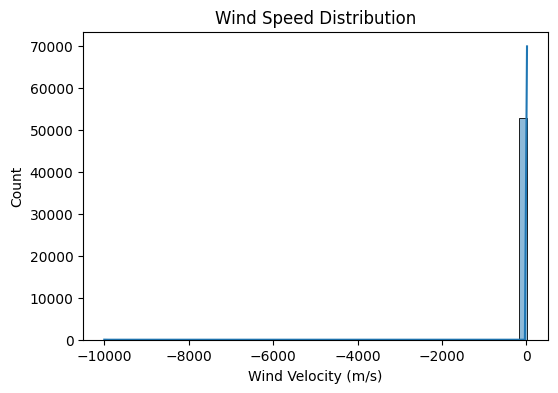

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['wv'], bins=50, kde=True)
plt.title("Wind Speed Distribution")
plt.xlabel("Wind Velocity (m/s)")
plt.show()

In [10]:
# Fit Weibull distribution
# floc=0 enforces a 2-parameter Weibull (standard for wind analysis)
shape_k, loc, scale_lambda = weibull_min.fit(df['wv'], floc=0)

In [11]:
print(f"Shape parameter (k): {shape_k:.3f}")
print(f"Scale parameter (λ): {scale_lambda:.3f}")

Shape parameter (k): 1.457
Scale parameter (λ): 2.426


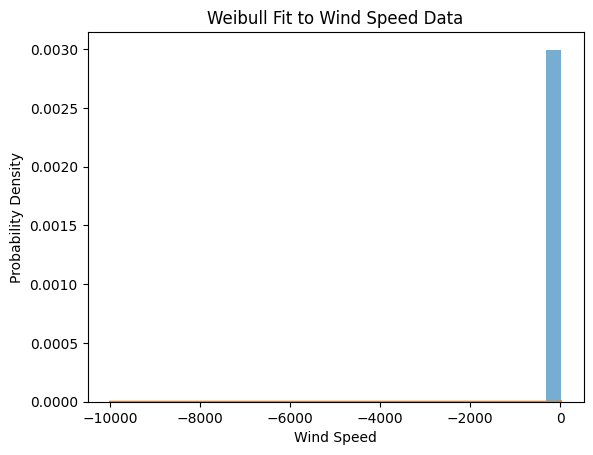

In [12]:
# Histogram of wind speed (Emprirical data)
plt.hist(df['wv'], bins=30, density=True, alpha=0.6)

# Weibull PDF (Theoretical fit)
x = np.linspace(df['wv'].min(), df['wv'].max(), 200)
pdf = weibull_min.pdf(x, shape_k, scale=scale_lambda)

plt.plot(x, pdf)
plt.xlabel("Wind Speed")
plt.ylabel("Probability Density")
plt.title("Weibull Fit to Wind Speed Data")
plt.show()

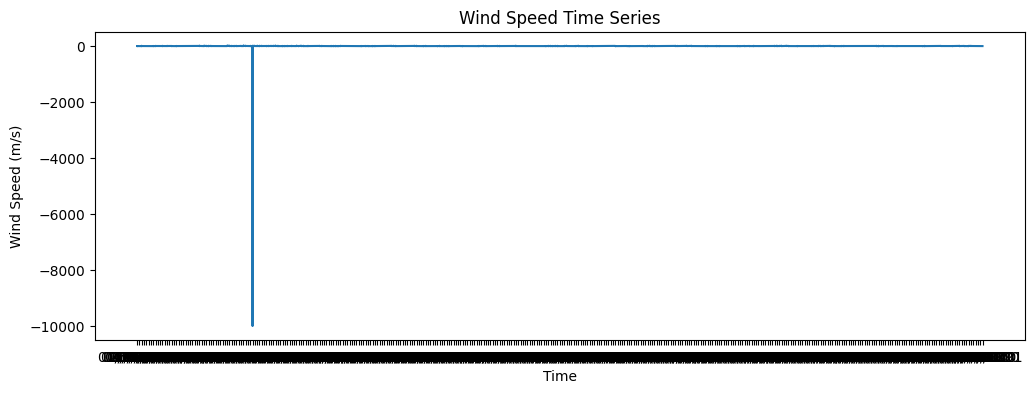

In [8]:
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['wv'])
plt.title("Wind Speed Time Series")
plt.xlabel("Time")
plt.ylabel("Wind Speed (m/s)")
plt.show()

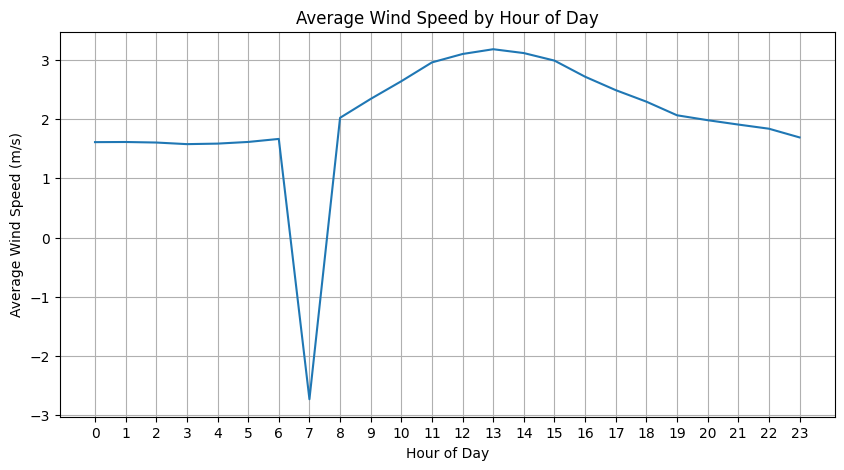

In [55]:
#Diurnal Cycle Analysis brcause Wind is strongly linked to solar radiation and thus shows a clear diurnal pattern. By analyzing the average wind speed for each hour of the day, we can identify when the wind tends to be strongest and weakest, which is crucial for forecasting and optimizing wind energy production.
df["hour"] = df["date"].dt.hour
hourly_wind = df.groupby("hour")["wv"].mean()
plt.figure(figsize=(10,5))
plt.plot(hourly_wind.index, hourly_wind.values)
plt.title("Average Wind Speed by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Wind Speed (m/s)")
plt.xticks(range(0,24))
plt.grid()
plt.show()

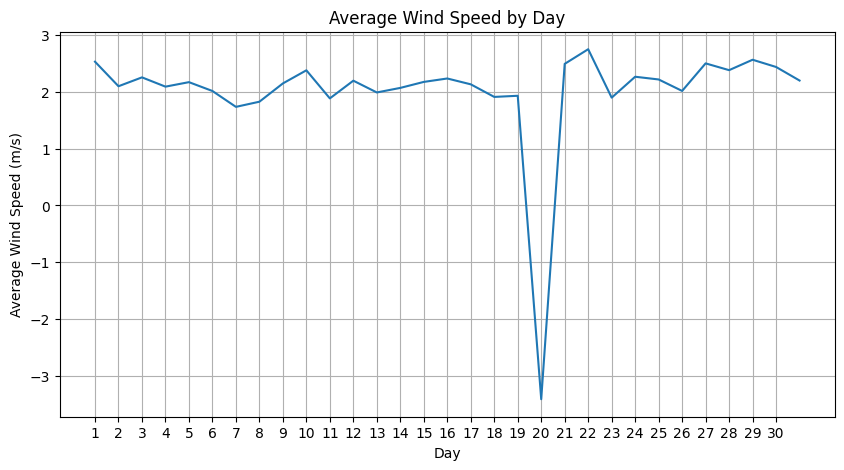

In [61]:
df["day"] = df["date"].dt.day
daily_wind = df.groupby("day")["wv"].mean()
plt.figure(figsize=(10,5))
plt.plot(daily_wind.index, daily_wind.values)
plt.title("Average Wind Speed by Day")
plt.xlabel("Day")
plt.ylabel("Average Wind Speed (m/s)")
plt.xticks(range(1,31))
plt.grid()
plt.show()

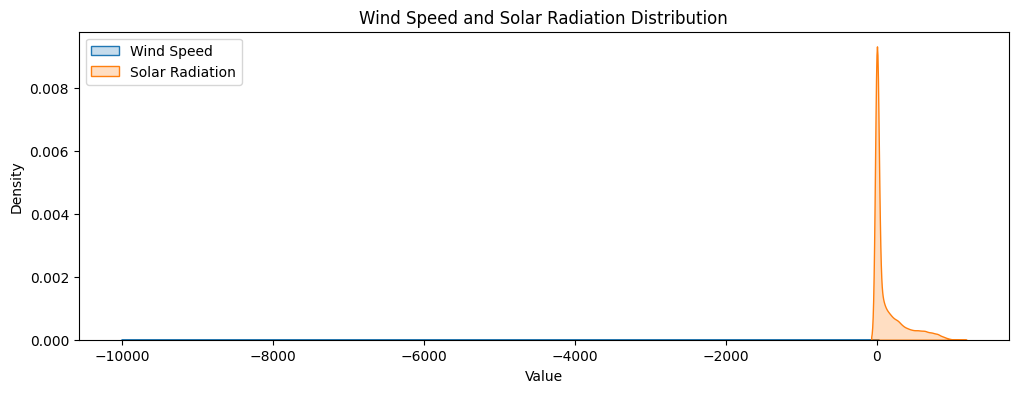

In [62]:
plt.figure(figsize=(12,4))
sns.kdeplot(df['wv'], fill=True)
sns.kdeplot(df['SWDR'], fill=True)
plt.title("Wind Speed and Solar Radiation Distribution")
plt.xlabel("Value")
plt.legend(["Wind Speed", "Solar Radiation"])
plt.show()

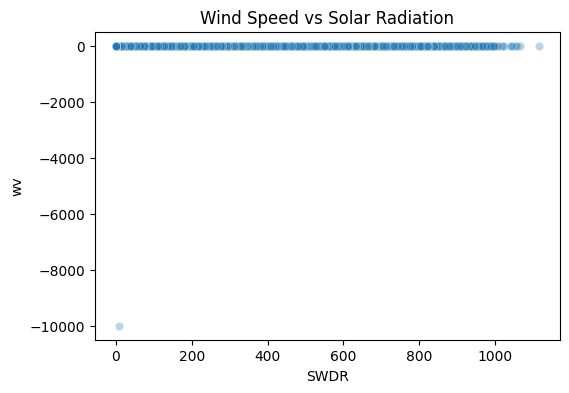

In [ ]:
# Radiation vs Wind correlation analysis is important because solar radiation can influence wind patterns. By examining the relationship between solar radiation and wind speed, we can better understand how changes in sunlight affect wind behavior, which is crucial for improving wind forecasting models and optimizing renewable energy production.
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["SWDR"], y=df["wv"], alpha=0.3)
plt.title("Wind Speed vs Solar Radiation")
plt.show()

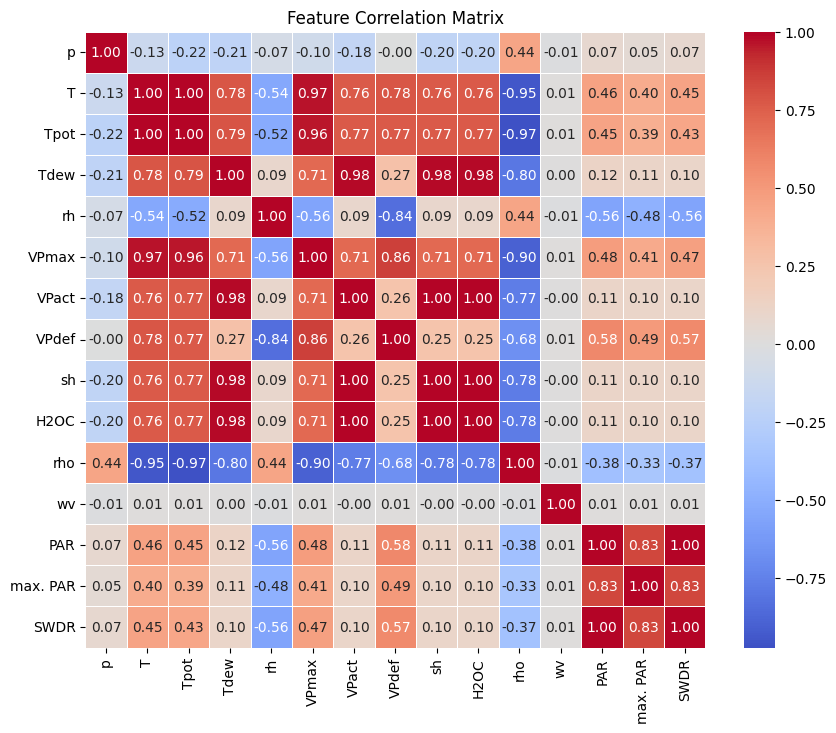

In [13]:
# Correlation Matrix
features = [
"p","T","Tpot","Tdew","rh","VPmax","VPact",
"VPdef","sh","H2OC","rho","wv","PAR","max. PAR","SWDR"
]

corr = df[features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

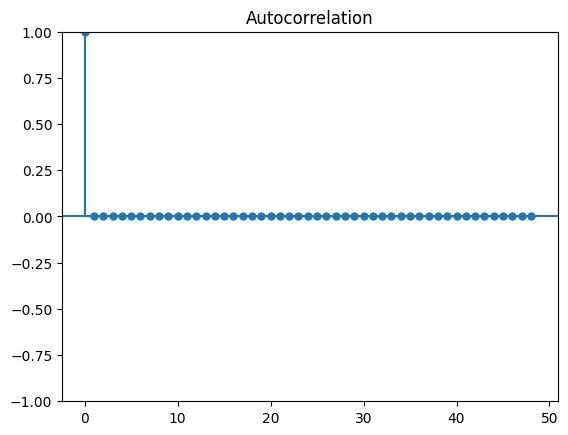

In [14]:
# Autocorrelation Analysis because Wind has temporal persistence and can be influenced by previous conditions. By analyzing the autocorrelation of wind speed, we can identify how past wind speeds affect future values, which is essential for developing accurate forecasting models.
plot_acf(df["wv"], lags=48)
plt.show()

In [ ]:
# Now we build the ML pipeline for wind forecasting

In [15]:
features = ["P","T","Tdew","rh","rho", "VPdef","sh","SWDR","par"]

In [16]:
# We will create lag features for the target variable (wind speed) to capture temporal dependencies. This is important because past wind speeds can influence future values, and including lagged features can help the model learn these patterns for better forecasting accuracy.
def create_lags(df, target, lags=6):
    
    for lag in range(1, lags+1):
        df[f"{target}_lag{lag}"] = df[target].shift(lag)
        
    return df

df = create_lags(df, "wv", 6)
df = df.dropna()

In [17]:
 # Split data into features and target for time series forecasting
train_size = int(len(df)*0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train.drop(["wv","date"], axis=1)
y_train = train["wv"]

X_test = test.drop(["wv","date"], axis=1)
y_test = test["wv"]

In [18]:
# Feature Scaling 

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
# Baseline Persistence Model
y_pred_persistence = test["wv_lag1"]

In [21]:
# Random Forest Regressor
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = model.predict(X_test)

In [23]:
# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.22475737938879994
RMSE: 0.29992323712498287


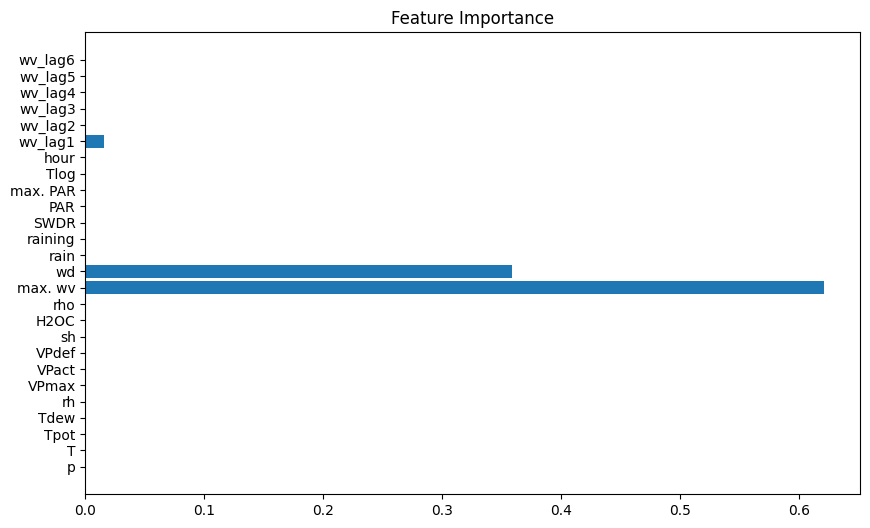

In [24]:
# Feature importance analysis is crucial for understanding which features have the most influence on the model's predictions. By analyzing feature importance, we can identify key drivers of wind speed and potentially improve our forecasting model by focusing on the most relevant features.
importance = model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(range(len(importance)), importance)
plt.yticks(range(len(importance)), train.drop(["wv","date"],axis=1).columns)
plt.title("Feature Importance")
plt.show()

In [25]:
# Last row of dataset
last_row = df.iloc[-1]

# Extract feature columns used in training
feature_columns = train.drop(["wv","date"], axis=1).columns

last_features = df[feature_columns].iloc[-1:].copy()

In [ ]:
# Future Prediction Function, This function recursively predicts future wind speed by using the last known features and updating them with each new prediction. This approach allows us to forecast multiple steps into the future while accounting for the temporal dependencies in the data.
def forecast_future(model, last_features, steps, scaler, feature_columns):

    predictions = []

    current_features = last_features.copy()

    for i in range(steps):

        # scale features
        scaled_features = scaler.transform(current_features)

        # predict wind speed
        pred = model.predict(scaled_features)[0]

        predictions.append(pred)

        # update lag features
        for lag in range(6,1,-1):
            current_features[f"wv_lag{lag}"] = current_features[f"wv_lag{lag-1}"]

        current_features["wv_lag1"] = pred

    return predictions

In [ ]:
# Forecast the next 24 hours of wind speed
future_steps = 24

future_predictions = forecast_future(
    model,
    last_features,
    future_steps,
    scaler,
    feature_columns
)

# These values represent predicted wind speed (m/s) for the next 24 hours based on the last known features and the trained Random Forest model.
print(list(future_predictions))

[np.float64(0.6299820453553443), np.float64(0.6302982114303171), np.float64(0.6304824968369392), np.float64(0.6304824968369392), np.float64(0.6304824968369392), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534), np.float64(0.6301939316031534)]


In [ ]:
# Create Future Time Index for the predicted values. This is important for visualizing the forecasted wind speeds in a time series context and for comparing them with actual future observations when they become available.
future_dates = pd.date_range(
    start=df["date"].iloc[-1],
    periods=future_steps+1,
    freq="h"
)[1:]

forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_wind_speed": future_predictions
})

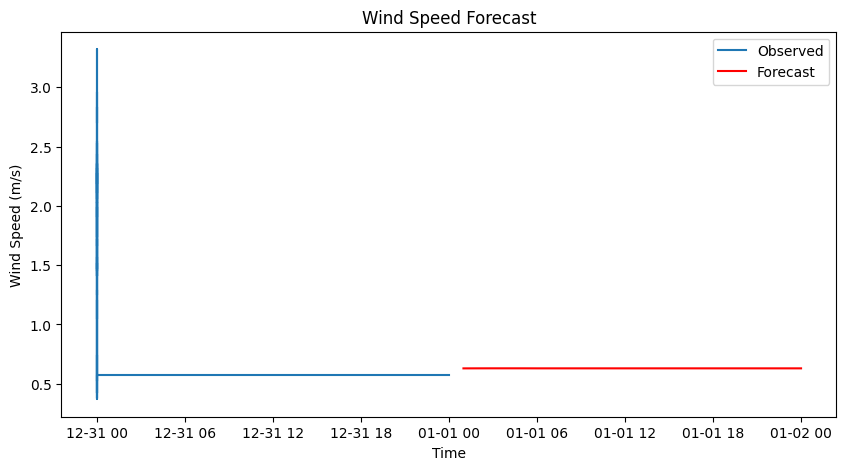

In [ ]:
# plotting the forecast, Visualize the observed wind speed and the forecasted values. This allows us to see how well the model's predictions align with the recent observed data and to understand the expected trend in wind speed over the next 24 hours.
plt.figure(figsize=(10,5))

plt.plot(df["date"].tail(100), df["wv"].tail(100), label="Observed")
plt.plot(forecast_df["date"], forecast_df["predicted_wind_speed"],
         label="Forecast", color="red")

plt.legend()
plt.title("Wind Speed Forecast")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")

plt.show()